# Multivariate `k = 0` QMC Normalizer Study

This notebook adapts the Sobol-bank normalizer idea from `examples/MCMC-HAL` to the multivariate HAL setting. It studies the `k = 0` case only and compares budget-matched midpoint and scrambled Sobol normalization banks against a high-resolution midpoint reference fit.

In [1]:
import sys
from pathlib import Path

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import logsumexp
from scipy.stats import qmc
from IPython.display import Markdown, display

# Ensure repo root is importable when the notebook is opened from nested folders.
root = Path.cwd().resolve()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from src.haldensity.multivariate import BivariateTruncatedNormal, build_midpoint_quadrature
from src.haldensity.utils.multivariate_basis import create_multivariate_basis

np.random.seed(0)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

CONFIG = {
    "n_train": 80,
    "n_valid": 1500,
    "train_seed": 123,
    "valid_seed": 456,
    "basis_order": 0,
    "norm_constraint": 8.0,
    "budgets": [64, 256, 1024],
    "reference_budget": 4096,
    "representative_seed": 7,
    "rep_seeds": list(range(20)),
    "solver": "MOSEK",
    "use_secondary_solver": True,
    "solver_waterfall": ["MOSEK", "ECOS", "CLARABEL", "SCS"],
    "eval_points_per_dim": 120,
    "theta_tol": 1e-4,
}

print(CONFIG)

{'n_train': 80, 'n_valid': 1500, 'train_seed': 123, 'valid_seed': 456, 'basis_order': 0, 'norm_constraint': 8.0, 'budgets': [64, 256, 1024], 'reference_budget': 4096, 'representative_seed': 7, 'rep_seeds': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], 'solver': 'MOSEK', 'use_secondary_solver': True, 'solver_waterfall': ['MOSEK', 'ECOS', 'CLARABEL', 'SCS'], 'eval_points_per_dim': 120, 'theta_tol': 0.0001}


/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def build_basis_matrix(
    points: pd.DataFrame | np.ndarray,
    knot_data: pd.DataFrame,
    basis_order: int,
) -> np.ndarray:
    basis, _, _ = create_multivariate_basis(
        points,
        k=basis_order,
        include_intercept=True,
        knot_data=knot_data,
    )
    return np.asarray(basis, dtype=float)


def stable_log_integral_from_weights(log_vals: np.ndarray, weights: np.ndarray) -> float:
    log_vals = np.asarray(log_vals, dtype=float)
    weights = np.asarray(weights, dtype=float)
    if log_vals.shape != weights.shape:
        raise ValueError("log_vals and weights must have the same shape")
    if np.any(weights <= 0.0):
        raise ValueError("weights must be strictly positive")
    return float(logsumexp(log_vals + np.log(weights)))


def density_from_logf(logf: np.ndarray, log_z: float) -> np.ndarray:
    return np.exp(np.clip(np.asarray(logf, dtype=float) - float(log_z), -700, 700))


def avg_loglik_from_basis(b_eval: np.ndarray, theta: np.ndarray, log_z: float) -> float:
    theta = np.asarray(theta, dtype=float)
    return float(np.mean(np.asarray(b_eval, dtype=float) @ theta - float(log_z)))


def solve_with_baseline_policy(
    problem: cp.Problem,
    primary_solver: str,
    use_secondary_solver: bool,
    waterfall: list[str],
) -> str:
    tried = []
    try:
        problem.solve(solver=primary_solver)
        return primary_solver
    except Exception as err:
        tried.append((primary_solver, err))
        if not use_secondary_solver:
            raise RuntimeError(f"Primary solver {primary_solver} failed: {err}")

    for solver_name in waterfall:
        if solver_name == primary_solver:
            continue
        try:
            if solver_name == "SCS":
                problem.solve(solver=solver_name, eps=5e-7, max_iters=100000)
            else:
                problem.solve(solver=solver_name)
            return solver_name
        except Exception as err2:
            tried.append((solver_name, err2))

    tried_msg = "; ".join([f"{name}: {type(err).__name__}({err})" for name, err in tried])
    raise RuntimeError(f"All solvers failed. Tried -> {tried_msg}")


def budget_to_points_per_dim(budget: int, dimension: int) -> int:
    points_per_dim = int(round(budget ** (1.0 / dimension)))
    if points_per_dim ** dimension != budget:
        raise ValueError(
            f"budget={budget} is not an exact {dimension}-dimensional tensor-product budget"
        )
    return points_per_dim


def make_sobol_bank(
    budget: int,
    support: tuple[tuple[float, float], ...],
    scramble_seed: int,
) -> tuple[np.ndarray, np.ndarray]:
    if budget <= 0 or (budget & (budget - 1)) != 0:
        raise ValueError("budget must be a positive power of two for Sobol random_base2")

    lower = np.array([bound[0] for bound in support], dtype=float)
    upper = np.array([bound[1] for bound in support], dtype=float)
    volume = float(np.prod(upper - lower))

    sob = qmc.Sobol(d=len(support), scramble=True, seed=scramble_seed)
    unit_points = sob.random_base2(m=int(np.log2(budget)))
    scaled_points = qmc.scale(unit_points, lower, upper)
    weights = np.full(budget, volume / budget, dtype=float)
    return scaled_points, weights


def prune_theta(theta: np.ndarray, basis_order: int, tol: float = 1e-4) -> np.ndarray:
    theta = np.asarray(theta, dtype=float).copy()
    start = basis_order + 1
    theta[start:] = np.where(np.abs(theta[start:]) > tol, theta[start:], 0.0)
    return theta


def selected_basis_index_set(theta: np.ndarray, basis_order: int, tol: float = 1e-4) -> set[int]:
    theta = np.asarray(theta, dtype=float)
    start = basis_order + 1
    return {int(index) for index in np.where(np.abs(theta[start:]) > tol)[0]}


def jaccard_overlap(a: set[int], b: set[int]) -> float:
    union = a | b
    return 1.0 if not union else len(a & b) / len(union)


def fit_midpoint_cvx(
    b_train: np.ndarray,
    knot_data: pd.DataFrame,
    basis_order: int,
    norm_constraint: float,
    budget: int,
    support: tuple[tuple[float, float], ...],
    solver: str = "MOSEK",
    use_secondary_solver: bool = True,
    solver_waterfall: list[str] | None = None,
    theta_tol: float = 1e-4,
):
    if solver_waterfall is None:
        solver_waterfall = ["MOSEK", "ECOS", "CLARABEL", "SCS"]

    points_per_dim = budget_to_points_per_dim(budget=budget, dimension=len(support))
    norm_points, norm_weights, _ = build_midpoint_quadrature(support, points_per_dim)
    b_norm = build_basis_matrix(norm_points, knot_data, basis_order)

    n, k = b_train.shape
    theta = cp.Variable(k)
    first_term = -cp.sum(b_train @ theta)
    log_z = cp.log_sum_exp(b_norm @ theta + np.log(norm_weights))
    loss = first_term + n * log_z
    constraints = [cp.norm1(theta[1:]) <= norm_constraint]
    problem = cp.Problem(cp.Minimize(loss), constraints)
    used_solver = solve_with_baseline_policy(problem, solver, use_secondary_solver, solver_waterfall)

    if theta.value is None:
        raise RuntimeError("Midpoint CVXPY optimization failed; theta.value is None")

    theta_hat_raw = np.asarray(theta.value, dtype=float)
    theta_hat = prune_theta(theta_hat_raw, basis_order=basis_order, tol=theta_tol)

    return {
        "method_family": "midpoint",
        "budget": budget,
        "seed": np.nan,
        "theta_hat": theta_hat,
        "theta_hat_raw": theta_hat_raw,
        "selected_basis_set": selected_basis_index_set(theta_hat, basis_order, theta_tol),
        "norm_points": norm_points,
        "norm_weights": norm_weights,
        "b_norm": b_norm,
        "used_solver": used_solver,
        "objective_value": float(problem.value),
    }


def fit_sobol_cvx(
    b_train: np.ndarray,
    knot_data: pd.DataFrame,
    basis_order: int,
    norm_constraint: float,
    budget: int,
    support: tuple[tuple[float, float], ...],
    scramble_seed: int,
    solver: str = "MOSEK",
    use_secondary_solver: bool = True,
    solver_waterfall: list[str] | None = None,
    theta_tol: float = 1e-4,
):
    if solver_waterfall is None:
        solver_waterfall = ["MOSEK", "ECOS", "CLARABEL", "SCS"]

    norm_points, norm_weights = make_sobol_bank(
        budget=budget,
        support=support,
        scramble_seed=scramble_seed,
    )
    b_norm = build_basis_matrix(norm_points, knot_data, basis_order)

    n, k = b_train.shape
    theta = cp.Variable(k)
    first_term = -cp.sum(b_train @ theta)
    log_z = cp.log_sum_exp(b_norm @ theta + np.log(norm_weights))
    loss = first_term + n * log_z
    constraints = [cp.norm1(theta[1:]) <= norm_constraint]
    problem = cp.Problem(cp.Minimize(loss), constraints)
    used_solver = solve_with_baseline_policy(problem, solver, use_secondary_solver, solver_waterfall)

    if theta.value is None:
        raise RuntimeError("Sobol CVXPY optimization failed; theta.value is None")

    theta_hat_raw = np.asarray(theta.value, dtype=float)
    theta_hat = prune_theta(theta_hat_raw, basis_order=basis_order, tol=theta_tol)

    return {
        "method_family": "sobol",
        "budget": budget,
        "seed": scramble_seed,
        "theta_hat": theta_hat,
        "theta_hat_raw": theta_hat_raw,
        "selected_basis_set": selected_basis_index_set(theta_hat, basis_order, theta_tol),
        "norm_points": norm_points,
        "norm_weights": norm_weights,
        "b_norm": b_norm,
        "used_solver": used_solver,
        "objective_value": float(problem.value),
    }


def compute_fit_metrics(
    fit: dict,
    b_valid: np.ndarray,
    b_eval: np.ndarray,
    eval_weights: np.ndarray,
    true_density_eval: np.ndarray,
):
    theta = np.asarray(fit["theta_hat"], dtype=float)
    logf_norm = np.asarray(fit["b_norm"], dtype=float) @ theta
    logf_eval = np.asarray(b_eval, dtype=float) @ theta

    logz_native = stable_log_integral_from_weights(logf_norm, fit["norm_weights"])
    logz_dense = stable_log_integral_from_weights(logf_eval, eval_weights)

    native_density_norm = density_from_logf(logf_norm, logz_native)
    native_density_eval = density_from_logf(logf_eval, logz_native)
    valid_avg_loglik_native = avg_loglik_from_basis(b_valid, theta, logz_native)

    return {
        "logZ_native": logz_native,
        "logZ_dense_midpoint": logz_dense,
        "abs_logZ_native_minus_dense_midpoint": abs(logz_native - logz_dense),
        "native_density_eval": native_density_eval,
        "heldout_avg_loglik_native": valid_avg_loglik_native,
        "native_normalization_residual": abs(
            float(np.sum(native_density_norm * fit["norm_weights"]) - 1.0)
        ),
        "dense_midpoint_mass": float(np.sum(native_density_eval * eval_weights)),
        "iae_to_truth": float(np.sum(np.abs(native_density_eval - true_density_eval) * eval_weights)),
        "pointwise_rmse": float(np.sqrt(np.mean((native_density_eval - true_density_eval) ** 2))),
        "pointwise_max_abs_error": float(np.max(np.abs(native_density_eval - true_density_eval))),
        "nonnegative_native_density_on_dense_grid": bool(np.all(native_density_eval >= 0.0)),
        "heldout_loglik_is_finite": bool(np.isfinite(valid_avg_loglik_native)),
    }

## Data Generation and Shared Basis Objects

We use the same synthetic bivariate truncated normal as the midpoint grid notebook, but now focus on `k = 0` only. The basis knots come from the training sample and stay fixed for every method and budget.

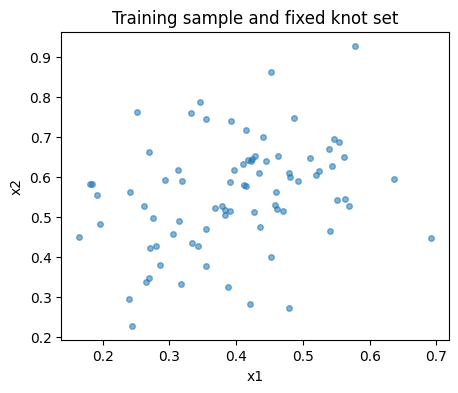

,x1,x2
0,0.553733,0.686491
1,0.270214,0.422330
2,0.275505,0.496601
3,0.439518,0.700472
4,0.480295,0.600430


basis_order                                      0
basis_width                                    241
n_train                                         80
n_valid                                       1500
evaluation_grid_points                       14400
support                   ((0.0, 1.0), (0.0, 1.0))
Name: value, dtype: object

In [3]:
dgp = BivariateTruncatedNormal(
    mean=(0.42, 0.58),
    covariance=[[0.018, 0.008], [0.008, 0.022]],
    lower=(0.0, 0.0),
    upper=(1.0, 1.0),
)
support = dgp.bounds

train_data = dgp.generate_samples(CONFIG["n_train"], seed=CONFIG["train_seed"])
valid_data = dgp.generate_samples(CONFIG["n_valid"], seed=CONFIG["valid_seed"])
knot_data = train_data.copy()

b_train = build_basis_matrix(train_data, knot_data, CONFIG["basis_order"])
b_valid = build_basis_matrix(valid_data, knot_data, CONFIG["basis_order"])
_, basis_names, basis_meta = create_multivariate_basis(
    train_data,
    k=CONFIG["basis_order"],
    include_intercept=True,
)

eval_points, eval_weights, eval_axes = build_midpoint_quadrature(
    support,
    CONFIG["eval_points_per_dim"],
)
b_eval = build_basis_matrix(eval_points, knot_data, CONFIG["basis_order"])
true_density_eval = dgp.compute_density(eval_points)

eval_mesh_x1, eval_mesh_x2 = np.meshgrid(eval_axes[0], eval_axes[1], indexing="ij")
true_density_eval_grid = true_density_eval.reshape(eval_mesh_x1.shape)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(train_data["x1"], train_data["x2"], s=16, alpha=0.55)
ax.set_title("Training sample and fixed knot set")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
plt.show()

display(train_data.head())
pd.Series(
    {
        "basis_order": CONFIG["basis_order"],
        "basis_width": b_train.shape[1],
        "n_train": CONFIG["n_train"],
        "n_valid": CONFIG["n_valid"],
        "evaluation_grid_points": eval_points.shape[0],
        "support": support,
    },
    name="value",
)

## Fit `midpoint_4096`, Budget-Matched Midpoint Fits, and Representative Sobol Fits

The reference fit uses a midpoint bank with total budget `4096 = 64 x 64`. Each smaller midpoint fit uses the matching tensor-product budget, while the Sobol method uses a scrambled fixed bank with the same total number of points.

In [4]:
reference_fit = fit_midpoint_cvx(
    b_train=b_train,
    knot_data=knot_data,
    basis_order=CONFIG["basis_order"],
    norm_constraint=CONFIG["norm_constraint"],
    budget=CONFIG["reference_budget"],
    support=support,
    solver=CONFIG["solver"],
    use_secondary_solver=CONFIG["use_secondary_solver"],
    solver_waterfall=CONFIG["solver_waterfall"],
    theta_tol=CONFIG["theta_tol"],
)
reference_metrics = compute_fit_metrics(
    fit=reference_fit,
    b_valid=b_valid,
    b_eval=b_eval,
    eval_weights=eval_weights,
    true_density_eval=true_density_eval,
)
reference_density_eval = reference_metrics["native_density_eval"]
reference_density_eval_grid = reference_density_eval.reshape(eval_mesh_x1.shape)
reference_valid_ll = reference_metrics["heldout_avg_loglik_native"]
reference_selected_set = reference_fit["selected_basis_set"]

representative_rows = [
    {
        "label": f"midpoint_{CONFIG['reference_budget']}",
        "model_family": "midpoint",
        "budget": CONFIG["reference_budget"],
        "seed": np.nan,
        "used_solver": reference_fit["used_solver"],
        "n_selected_basis": len(reference_selected_set),
        "selected_basis_jaccard_vs_midpoint_ref": 1.0,
        "heldout_ll_gap_to_midpoint_ref": 0.0,
        "iad_to_midpoint_ref": 0.0,
        **reference_metrics,
    }
]

midpoint_rep_fits = {}
for budget in CONFIG["budgets"]:
    fit = fit_midpoint_cvx(
        b_train=b_train,
        knot_data=knot_data,
        basis_order=CONFIG["basis_order"],
        norm_constraint=CONFIG["norm_constraint"],
        budget=budget,
        support=support,
        solver=CONFIG["solver"],
        use_secondary_solver=CONFIG["use_secondary_solver"],
        solver_waterfall=CONFIG["solver_waterfall"],
        theta_tol=CONFIG["theta_tol"],
    )
    midpoint_rep_fits[budget] = fit
    metrics = compute_fit_metrics(
        fit=fit,
        b_valid=b_valid,
        b_eval=b_eval,
        eval_weights=eval_weights,
        true_density_eval=true_density_eval,
    )
    representative_rows.append(
        {
            "label": f"midpoint_{budget}",
            "model_family": "midpoint",
            "budget": budget,
            "seed": np.nan,
            "used_solver": fit["used_solver"],
            "n_selected_basis": len(fit["selected_basis_set"]),
            "selected_basis_jaccard_vs_midpoint_ref": jaccard_overlap(
                fit["selected_basis_set"],
                reference_selected_set,
            ),
            "heldout_ll_gap_to_midpoint_ref": abs(
                metrics["heldout_avg_loglik_native"] - reference_valid_ll
            ),
            "iad_to_midpoint_ref": float(
                np.sum(np.abs(metrics["native_density_eval"] - reference_density_eval) * eval_weights)
            ),
            **metrics,
        }
    )

sobol_rep_fits = {}
for budget in CONFIG["budgets"]:
    fit = fit_sobol_cvx(
        b_train=b_train,
        knot_data=knot_data,
        basis_order=CONFIG["basis_order"],
        norm_constraint=CONFIG["norm_constraint"],
        budget=budget,
        support=support,
        scramble_seed=CONFIG["representative_seed"],
        solver=CONFIG["solver"],
        use_secondary_solver=CONFIG["use_secondary_solver"],
        solver_waterfall=CONFIG["solver_waterfall"],
        theta_tol=CONFIG["theta_tol"],
    )
    sobol_rep_fits[budget] = fit
    metrics = compute_fit_metrics(
        fit=fit,
        b_valid=b_valid,
        b_eval=b_eval,
        eval_weights=eval_weights,
        true_density_eval=true_density_eval,
    )
    representative_rows.append(
        {
            "label": f"sobol_{budget}_seed{CONFIG['representative_seed']}",
            "model_family": "sobol",
            "budget": budget,
            "seed": CONFIG["representative_seed"],
            "used_solver": fit["used_solver"],
            "n_selected_basis": len(fit["selected_basis_set"]),
            "selected_basis_jaccard_vs_midpoint_ref": jaccard_overlap(
                fit["selected_basis_set"],
                reference_selected_set,
            ),
            "heldout_ll_gap_to_midpoint_ref": abs(
                metrics["heldout_avg_loglik_native"] - reference_valid_ll
            ),
            "iad_to_midpoint_ref": float(
                np.sum(np.abs(metrics["native_density_eval"] - reference_density_eval) * eval_weights)
            ),
            **metrics,
        }
    )

rep_metrics_table = pd.DataFrame(representative_rows).sort_values(
    ["model_family", "budget", "seed"],
    na_position="first",
)

summary_cols = [
    "label",
    "model_family",
    "budget",
    "seed",
    "heldout_ll_gap_to_midpoint_ref",
    "iad_to_midpoint_ref",
    "abs_logZ_native_minus_dense_midpoint",
    "dense_midpoint_mass",
    "native_normalization_residual",
    "iae_to_truth",
    "pointwise_rmse",
    "n_selected_basis",
    "selected_basis_jaccard_vs_midpoint_ref",
    "used_solver",
]
rep_metrics_table[summary_cols]

,label,model_family,budget,seed,heldout_ll_gap_to_midpoint_ref,iad_to_midpoint_ref,abs_logZ_native_minus_dense_midpoint,dense_midpoint_mass,native_normalization_residual,iae_to_truth,pointwise_rmse,n_selected_basis,selected_basis_jaccard_vs_midpoint_ref,used_solver
1,midpoint_64,midpoint,64,NaN,0.733859,2.151638,1.102579,3.011924,6.661338e-16,2.304432,6.109987,8,0.090909,ECOS
2,midpoint_256,midpoint,256,NaN,0.243185,0.643049,0.406336,1.501307,2.220446e-16,0.922127,2.082306,9,0.190476,ECOS
3,midpoint_1024,midpoint,1024,NaN,0.064770,0.197003,0.097882,1.102833,2.220446e-16,0.513993,0.818097,20,0.200000,ECOS
0,midpoint_4096,midpoint,4096,NaN,0.000000,0.000000,0.038761,1.039522,9.992007e-16,0.532575,0.860463,16,1.000000,ECOS
4,sobol_64_seed7,sobol,64,7.0,0.221250,0.475619,0.307288,1.359732,4.440892e-16,0.708566,1.328928,13,0.318182,ECOS
5,sobol_256_seed7,sobol,256,7.0,0.005562,0.118362,0.049569,1.050819,3.330669e-16,0.571098,0.954814,15,0.631579,ECOS
6,sobol_1024_seed7,sobol,1024,7.0,0.040672,0.103097,0.003383,0.996622,3.330669e-16,0.529478,0.859140,18,0.619048,ECOS


## Representative Contour Comparison

The top row shows the truth and the budget-matched midpoint family. The bottom row shows the high-resolution midpoint reference and the representative scrambled Sobol-bank fits. All fit panels overlay the true density contours in white.

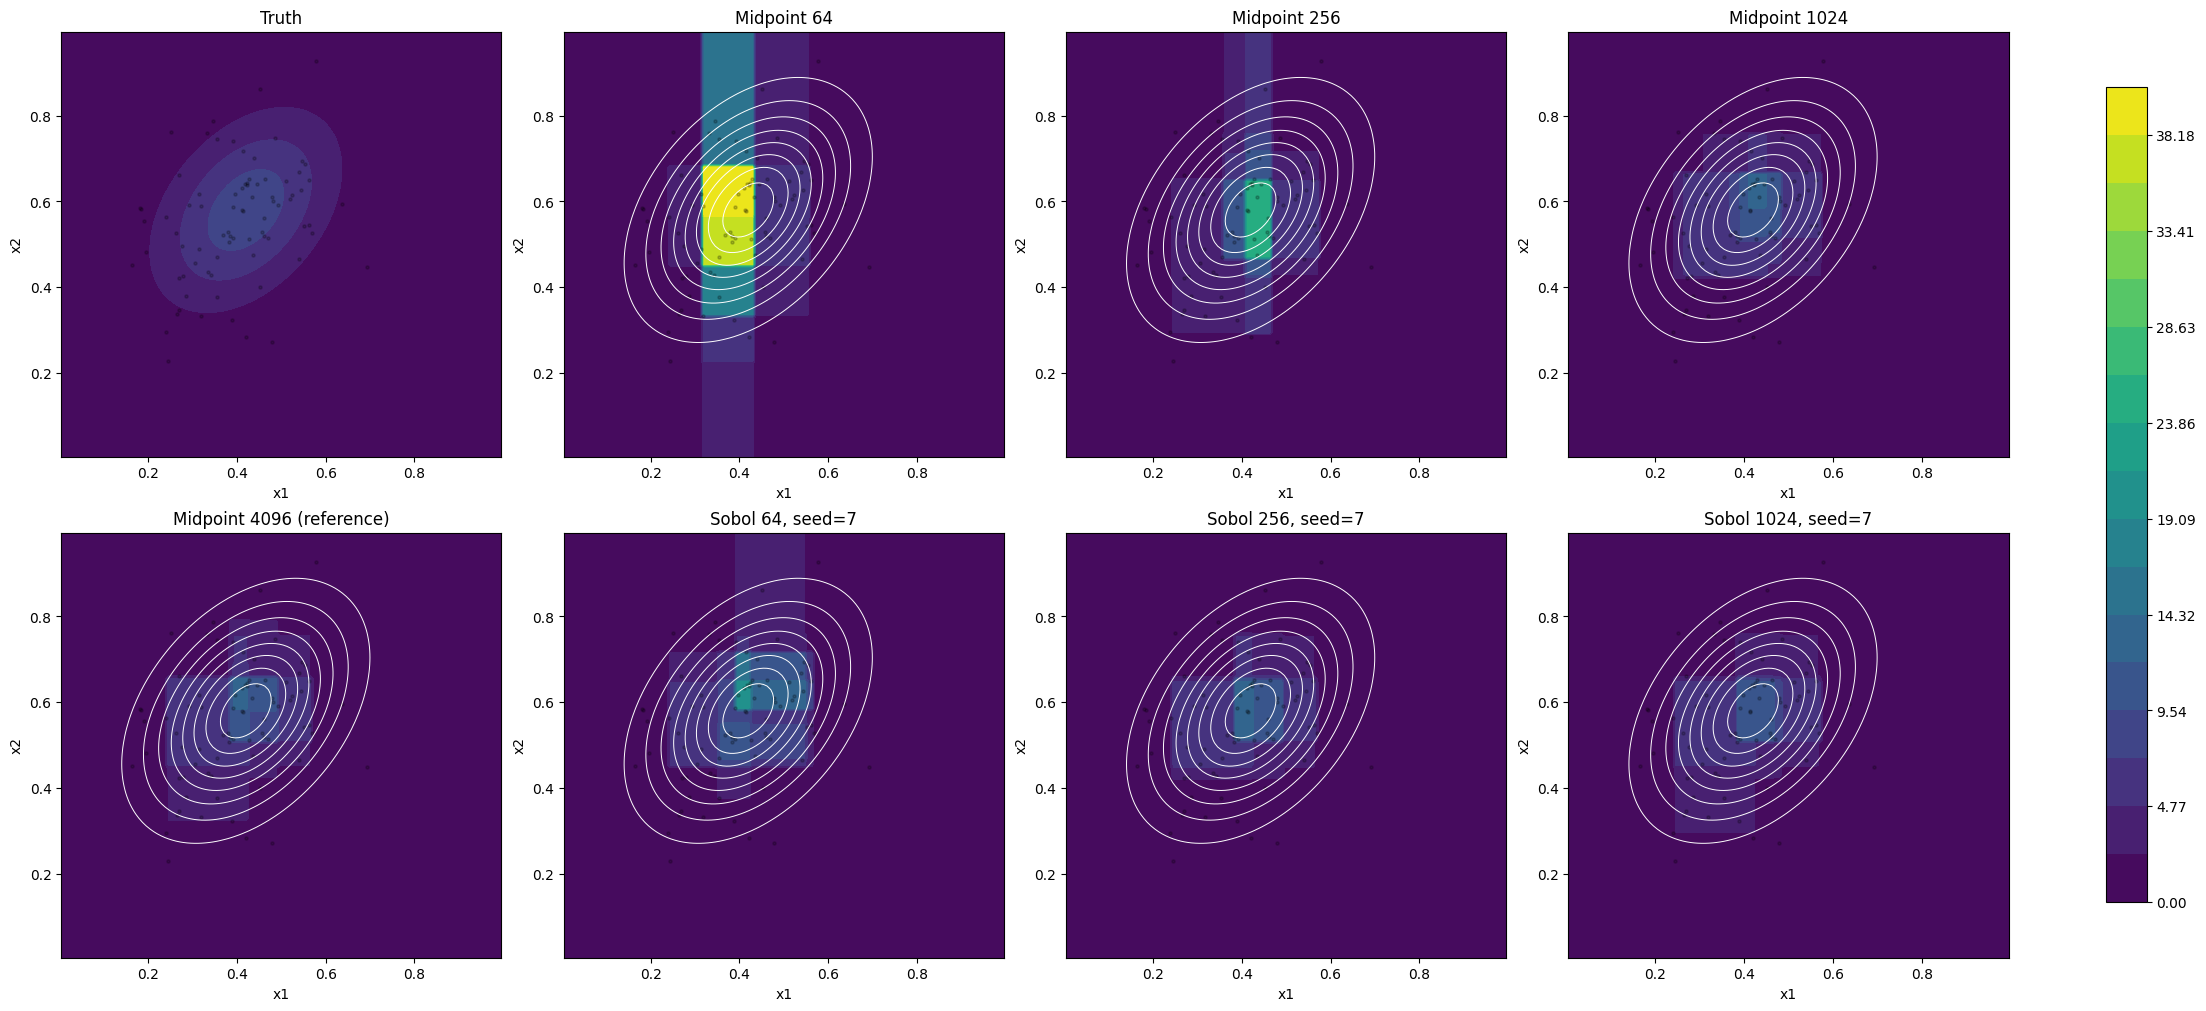

In [5]:
plot_vmax = max(
    float(np.max(true_density_eval_grid)),
    float(np.max(reference_density_eval_grid)),
    *[
        float(
            np.max(
                rep_metrics_table.loc[
                    rep_metrics_table["label"].eq(f"midpoint_{budget}"),
                    "native_density_eval",
                ].iloc[0].reshape(eval_mesh_x1.shape)
            )
        )
        for budget in CONFIG["budgets"]
    ],
    *[
        float(
            np.max(
                rep_metrics_table.loc[
                    rep_metrics_table["label"].eq(
                        f"sobol_{budget}_seed{CONFIG['representative_seed']}"
                    ),
                    "native_density_eval",
                ].iloc[0].reshape(eval_mesh_x1.shape)
            )
        )
        for budget in CONFIG["budgets"]
    ],
)
levels = np.linspace(0.0, plot_vmax, 18)

fig, axes = plt.subplots(2, 4, figsize=(22, 10), constrained_layout=True)

truth_panel = axes[0, 0].contourf(
    eval_mesh_x1,
    eval_mesh_x2,
    true_density_eval_grid,
    levels=levels,
    cmap="viridis",
)
axes[0, 0].scatter(train_data["x1"], train_data["x2"], s=5, color="black", alpha=0.20)
axes[0, 0].set_title("Truth")
axes[0, 0].set_xlabel("x1")
axes[0, 0].set_ylabel("x2")

for ax, budget in zip(axes[0, 1:], CONFIG["budgets"]):
    density_grid = rep_metrics_table.loc[
        rep_metrics_table["label"].eq(f"midpoint_{budget}"),
        "native_density_eval",
    ].iloc[0].reshape(eval_mesh_x1.shape)
    ax.contourf(eval_mesh_x1, eval_mesh_x2, density_grid, levels=levels, cmap="viridis")
    ax.contour(eval_mesh_x1, eval_mesh_x2, true_density_eval_grid, levels=8, colors="white", linewidths=0.7)
    ax.scatter(train_data["x1"], train_data["x2"], s=5, color="black", alpha=0.20)
    ax.set_title(f"Midpoint {budget}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

axes[1, 0].contourf(
    eval_mesh_x1,
    eval_mesh_x2,
    reference_density_eval_grid,
    levels=levels,
    cmap="viridis",
)
axes[1, 0].contour(eval_mesh_x1, eval_mesh_x2, true_density_eval_grid, levels=8, colors="white", linewidths=0.7)
axes[1, 0].scatter(train_data["x1"], train_data["x2"], s=5, color="black", alpha=0.20)
axes[1, 0].set_title(f"Midpoint {CONFIG['reference_budget']} (reference)")
axes[1, 0].set_xlabel("x1")
axes[1, 0].set_ylabel("x2")

for ax, budget in zip(axes[1, 1:], CONFIG["budgets"]):
    density_grid = rep_metrics_table.loc[
        rep_metrics_table["label"].eq(f"sobol_{budget}_seed{CONFIG['representative_seed']}"),
        "native_density_eval",
    ].iloc[0].reshape(eval_mesh_x1.shape)
    ax.contourf(eval_mesh_x1, eval_mesh_x2, density_grid, levels=levels, cmap="viridis")
    ax.contour(eval_mesh_x1, eval_mesh_x2, true_density_eval_grid, levels=8, colors="white", linewidths=0.7)
    ax.scatter(train_data["x1"], train_data["x2"], s=5, color="black", alpha=0.20)
    ax.set_title(f"Sobol {budget}, seed={CONFIG['representative_seed']}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

fig.colorbar(truth_panel, ax=axes, shrink=0.88)
plt.show()

## Sobol Bank Sensitivity Study

The deterministic table above uses one representative scramble. This section repeats the Sobol fit across multiple scramble seeds at each budget, so we can see how sensitive the approximation is to the random bank realization.

In [6]:
robust_rows = []

for budget in CONFIG["budgets"]:
    for seed in CONFIG["rep_seeds"]:
        fit = fit_sobol_cvx(
            b_train=b_train,
            knot_data=knot_data,
            basis_order=CONFIG["basis_order"],
            norm_constraint=CONFIG["norm_constraint"],
            budget=budget,
            support=support,
            scramble_seed=seed,
            solver=CONFIG["solver"],
            use_secondary_solver=CONFIG["use_secondary_solver"],
            solver_waterfall=CONFIG["solver_waterfall"],
            theta_tol=CONFIG["theta_tol"],
        )
        metrics = compute_fit_metrics(
            fit=fit,
            b_valid=b_valid,
            b_eval=b_eval,
            eval_weights=eval_weights,
            true_density_eval=true_density_eval,
        )
        robust_rows.append(
            {
                "budget": budget,
                "seed": seed,
                "used_solver": fit["used_solver"],
                "n_selected_basis": len(fit["selected_basis_set"]),
                "selected_basis_jaccard_vs_midpoint_ref": jaccard_overlap(
                    fit["selected_basis_set"],
                    reference_selected_set,
                ),
                "heldout_ll_gap_to_midpoint_ref": abs(
                    metrics["heldout_avg_loglik_native"] - reference_valid_ll
                ),
                "iad_to_midpoint_ref": float(
                    np.sum(np.abs(metrics["native_density_eval"] - reference_density_eval) * eval_weights)
                ),
                **metrics,
            }
        )

robust_df = pd.DataFrame(robust_rows).sort_values(["budget", "seed"])
robust_df.head()

,budget,seed,used_solver,n_selected_basis,selected_basis_jaccard_vs_midpoint_ref,heldout_ll_gap_to_midpoint_ref,iad_to_midpoint_ref,logZ_native,logZ_dense_midpoint,abs_logZ_native_minus_dense_midpoint,native_density_eval,heldout_avg_loglik_native,native_normalization_residual,dense_midpoint_mass,iae_to_truth,pointwise_rmse,pointwise_max_abs_error,nonnegative_native_density_on_dense_grid,heldout_loglik_is_finite
0,64,0,ECOS,14,0.250000,0.091012,0.313364,0.233131,0.358272,0.125141,"[0.6272907705622216, 0.6272907705622216, 0.627...",1.020521,4.440892e-16,1.133308,0.553141,0.952166,7.250215,True,True
1,64,1,ECOS,10,0.238095,0.277136,0.670966,0.153712,0.582544,0.428832,"[0.7354604326119474, 0.7354604326119474, 0.735...",1.206646,2.220446e-16,1.535462,0.954756,2.049238,13.724707,True,True
2,64,2,ECOS,12,0.272727,0.172784,0.524509,0.213567,0.514818,0.301250,"[0.6523708326192051, 0.6523708326192051, 0.652...",1.102293,2.220446e-16,1.351548,0.769818,1.459533,10.572927,True,True
3,64,3,ECOS,11,0.173913,0.183754,0.790333,0.139045,0.593515,0.454470,"[0.7572207514028989, 0.7572207514028989, 0.757...",1.113264,3.330669e-16,1.575338,1.048595,2.410506,15.971646,True,True
4,64,4,ECOS,11,0.285714,0.253479,0.658258,0.189839,0.570249,0.380410,"[0.6840700620082156, 0.6840700620082156, 0.684...",1.182989,2.220446e-16,1.462884,0.854617,1.907143,14.751751,True,True


## Summary Tables

The first table keeps the deterministic representative midpoint-versus-Sobol comparison. The second table summarizes the repeated Sobol runs with mean, median, and 10/90 percentiles.

In [7]:
def q10(x):
    return float(np.quantile(np.asarray(x, dtype=float), 0.10))


def q90(x):
    return float(np.quantile(np.asarray(x, dtype=float), 0.90))


display(rep_metrics_table[summary_cols])

sobol_summary = (
    robust_df.groupby("budget")[[
        "heldout_ll_gap_to_midpoint_ref",
        "iad_to_midpoint_ref",
        "abs_logZ_native_minus_dense_midpoint",
        "dense_midpoint_mass",
        "selected_basis_jaccard_vs_midpoint_ref",
        "pointwise_rmse",
    ]]
    .agg(["mean", "median", q10, q90])
)

sobol_summary

,label,model_family,budget,seed,heldout_ll_gap_to_midpoint_ref,iad_to_midpoint_ref,abs_logZ_native_minus_dense_midpoint,dense_midpoint_mass,native_normalization_residual,iae_to_truth,pointwise_rmse,n_selected_basis,selected_basis_jaccard_vs_midpoint_ref,used_solver
1,midpoint_64,midpoint,64,NaN,0.733859,2.151638,1.102579,3.011924,6.661338e-16,2.304432,6.109987,8,0.090909,ECOS
2,midpoint_256,midpoint,256,NaN,0.243185,0.643049,0.406336,1.501307,2.220446e-16,0.922127,2.082306,9,0.190476,ECOS
3,midpoint_1024,midpoint,1024,NaN,0.064770,0.197003,0.097882,1.102833,2.220446e-16,0.513993,0.818097,20,0.200000,ECOS
0,midpoint_4096,midpoint,4096,NaN,0.000000,0.000000,0.038761,1.039522,9.992007e-16,0.532575,0.860463,16,1.000000,ECOS
4,sobol_64_seed7,sobol,64,7.0,0.221250,0.475619,0.307288,1.359732,4.440892e-16,0.708566,1.328928,13,0.318182,ECOS
5,sobol_256_seed7,sobol,256,7.0,0.005562,0.118362,0.049569,1.050819,3.330669e-16,0.571098,0.954814,15,0.631579,ECOS
6,sobol_1024_seed7,sobol,1024,7.0,0.040672,0.103097,0.003383,0.996622,3.330669e-16,0.529478,0.859140,18,0.619048,ECOS


heldout_ll_gap_to_midpoint_ref                               iad_to_midpoint_ref                               abs_logZ_native_minus_dense_midpoint                               dense_midpoint_mass            \
                                 mean    median       q10       q90                mean    median       q10       q90                                 mean    median       q10       q90                mean    median   
budget                                                                                                                                                                                                                   
64                           0.199222  0.201185  0.137719  0.260676            0.556696  0.530269  0.405146  0.727418                             0.325015  0.319613  0.234370  0.439242            1.388907  1.376635   
256                          0.011020  0.006718  0.001397  0.029381            0.163345  0.152806  0.125355  0.210002                             0.045951  0.047012  0.013705  0.082612            1.047420  1.048138   
1024                         0.037545  0.037833  0.032654  0.041743            0.109915  0.111198  0.100147  0.117997                             0.005679  0.005386  0.001052  0.010659            0.995252  0.995457   

                           selected_basis_jaccard_vs_midpoint_ref                               pointwise_rmse                                
             q10       q90                                   mean    median       q10       q90           mean    median       q10       q90  
budget                                                                                                                                        
64      1.264147  1.551551                               0.232527  0.232684  0.171337  0.305731       1.722576  1.624687  1.235801  2.300557  
256     1.013802  1.086127                               0.426978  0.431677  0.333333  0.506522       0.922379  0.924490  0.812472  1.027855  
1024    0.989397  1.001235                               0.482686  0.478261  0.412500  0.550000       0.840472  0.840260  0.820222  0.855064

## Budget-vs-Gap Comparison

These curves show how fast midpoint and Sobol banks approach the high-resolution midpoint reference as the total normalization budget grows.

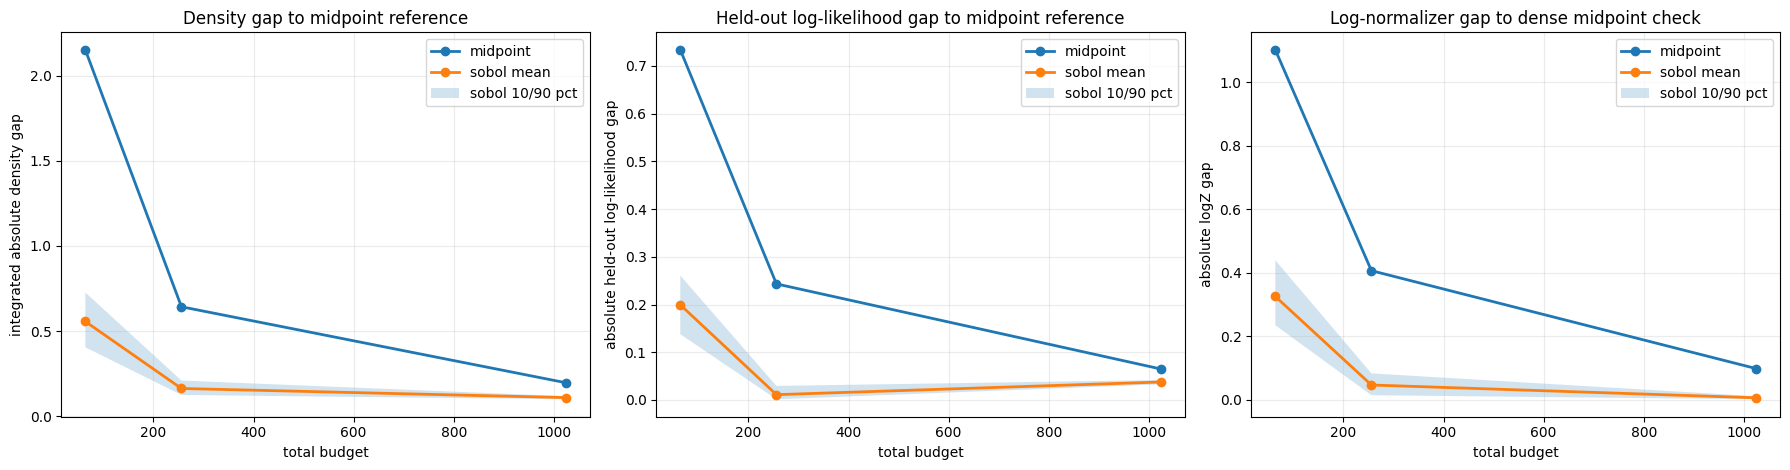

In [8]:
midpoint_curve = rep_metrics_table[
    (rep_metrics_table["model_family"] == "midpoint")
    & (rep_metrics_table["budget"] != CONFIG["reference_budget"])
].sort_values("budget")

sobol_gap_summary = robust_df.groupby("budget").agg(
    ll_gap_mean=("heldout_ll_gap_to_midpoint_ref", "mean"),
    ll_gap_q10=("heldout_ll_gap_to_midpoint_ref", q10),
    ll_gap_q90=("heldout_ll_gap_to_midpoint_ref", q90),
    iad_mean=("iad_to_midpoint_ref", "mean"),
    iad_q10=("iad_to_midpoint_ref", q10),
    iad_q90=("iad_to_midpoint_ref", q90),
    logz_gap_mean=("abs_logZ_native_minus_dense_midpoint", "mean"),
    logz_gap_q10=("abs_logZ_native_minus_dense_midpoint", q10),
    logz_gap_q90=("abs_logZ_native_minus_dense_midpoint", q90),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

axes[0].plot(
    midpoint_curve["budget"],
    midpoint_curve["iad_to_midpoint_ref"],
    marker="o",
    lw=2,
    label="midpoint",
)
axes[0].plot(
    sobol_gap_summary["budget"],
    sobol_gap_summary["iad_mean"],
    marker="o",
    lw=2,
    label="sobol mean",
)
axes[0].fill_between(
    sobol_gap_summary["budget"],
    sobol_gap_summary["iad_q10"],
    sobol_gap_summary["iad_q90"],
    alpha=0.2,
    label="sobol 10/90 pct",
)
axes[0].set_title("Density gap to midpoint reference")
axes[0].set_xlabel("total budget")
axes[0].set_ylabel("integrated absolute density gap")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(
    midpoint_curve["budget"],
    midpoint_curve["heldout_ll_gap_to_midpoint_ref"],
    marker="o",
    lw=2,
    label="midpoint",
)
axes[1].plot(
    sobol_gap_summary["budget"],
    sobol_gap_summary["ll_gap_mean"],
    marker="o",
    lw=2,
    label="sobol mean",
)
axes[1].fill_between(
    sobol_gap_summary["budget"],
    sobol_gap_summary["ll_gap_q10"],
    sobol_gap_summary["ll_gap_q90"],
    alpha=0.2,
    label="sobol 10/90 pct",
)
axes[1].set_title("Held-out log-likelihood gap to midpoint reference")
axes[1].set_xlabel("total budget")
axes[1].set_ylabel("absolute held-out log-likelihood gap")
axes[1].grid(alpha=0.25)
axes[1].legend()

axes[2].plot(
    midpoint_curve["budget"],
    midpoint_curve["abs_logZ_native_minus_dense_midpoint"],
    marker="o",
    lw=2,
    label="midpoint",
)
axes[2].plot(
    sobol_gap_summary["budget"],
    sobol_gap_summary["logz_gap_mean"],
    marker="o",
    lw=2,
    label="sobol mean",
)
axes[2].fill_between(
    sobol_gap_summary["budget"],
    sobol_gap_summary["logz_gap_q10"],
    sobol_gap_summary["logz_gap_q90"],
    alpha=0.2,
    label="sobol 10/90 pct",
)
axes[2].set_title("Log-normalizer gap to dense midpoint check")
axes[2].set_xlabel("total budget")
axes[2].set_ylabel("absolute logZ gap")
axes[2].grid(alpha=0.25)
axes[2].legend()

plt.tight_layout()
plt.show()

## Validity Checks and Conclusion

The native bank always normalizes itself by construction, so the more informative diagnostics are the dense-midpoint mass check, the log-normalizer gap, the holdout log-likelihood gap, and the density gap to the midpoint reference.

In [9]:
validity_table = rep_metrics_table[[
    "label",
    "model_family",
    "budget",
    "seed",
    "native_normalization_residual",
    "dense_midpoint_mass",
    "heldout_avg_loglik_native",
    "heldout_ll_gap_to_midpoint_ref",
    "iad_to_midpoint_ref",
    "abs_logZ_native_minus_dense_midpoint",
    "iae_to_truth",
    "pointwise_rmse",
    "selected_basis_jaccard_vs_midpoint_ref",
    "nonnegative_native_density_on_dense_grid",
    "heldout_loglik_is_finite",
]].copy()

validity_table["dense_midpoint_mass_in_[0.95,1.05]"] = validity_table["dense_midpoint_mass"].between(0.95, 1.05)
validity_table["native_norm_residual_small"] = validity_table["native_normalization_residual"] < 1e-8
validity_table

midpoint_best = midpoint_curve.loc[midpoint_curve["iad_to_midpoint_ref"].idxmin()]
sobol_median_best = (
    robust_df.groupby("budget")["iad_to_midpoint_ref"]
    .median()
    .sort_values()
    .index[0]
)
sobol_stability = robust_df.groupby("budget")["selected_basis_jaccard_vs_midpoint_ref"].median()

summary_md = f"""
### Reading of the `k = 0` QMC Experiment

- The high-resolution reference is `midpoint_{CONFIG['reference_budget']}`.
- Among the budget-matched midpoint fits, the smallest density gap to the reference occurs at budget `{int(midpoint_best['budget'])}`.
- Among the repeated Sobol fits, the best median density gap occurs at budget `{int(sobol_median_best)}`.
- The median Sobol selected-basis overlap with the midpoint reference is `{sobol_stability.loc[sobol_median_best]:.3f}` at that best Sobol budget.

In this notebook, the key question is not whether Sobol banks normalize themselves natively, because they do by construction, but whether they recover a density close to the high-resolution midpoint reference on a dense midpoint check grid.
"""

display(Markdown(summary_md))


### Reading of the `k = 0` QMC Experiment

- The high-resolution reference is `midpoint_4096`.
- Among the budget-matched midpoint fits, the smallest density gap to the reference occurs at budget `1024`.
- Among the repeated Sobol fits, the best median density gap occurs at budget `1024`.
- The median Sobol selected-basis overlap with the midpoint reference is `0.478` at that best Sobol budget.

In this notebook, the key question is not whether Sobol banks normalize themselves natively, because they do by construction, but whether they recover a density close to the high-resolution midpoint reference on a dense midpoint check grid.
